# 05 — What a returned probability is worth, and what the leaks cost

Ranking is not everything. This notebook reads the probability scale the model returns, the
images it misses, and the price of the three leaks the first version of the protocol carried.

In [1]:
import numpy as np
import pandas as pd

from mri_semisupervised.config import EXPERIMENTS_DIR
from mri_semisupervised.protocol.uncertainty import paired_difference

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 20)

per_fold = pd.read_parquet(EXPERIMENTS_DIR / "corrected" / "per_fold.parquet")
predictions = pd.read_parquet(EXPERIMENTS_DIR / "corrected" / "predictions.parquet")
folds = pd.read_parquet(EXPERIMENTS_DIR / "corrected" / "folds.parquet")

#: The five metrics every table of these notebooks reports, in one order.
headline = ["roc_auc", "pr_auc", "recall_positive", "f1_macro", "accuracy"]

## 1. What a returned probability is worth

The protocol publishes scores. Whether they mean anything as probabilities is a separate
question, and ROC AUC cannot answer it: a model whose ranking is perfect and whose scale is
squashed scores 1.0 either way.

In [2]:
from mri_semisupervised.protocol.calibration import summarise_calibration

summary, curves = summarise_calibration(predictions, n_bins=10)
display(summary.round(4))

sup = curves["supervised"]
display(sup[["mean_score", "observed", "gap"]].round(3))

,arm,n,brier,ece,mean_score,base_rate
0,permuted_control,495,0.0875,0.0327,0.5044,0.5051
1,semi_supervised,495,0.1073,0.0953,0.4442,0.5051
2,semi_supervised_confident,495,0.1084,0.1102,0.4357,0.5051
3,supervised,495,0.1040,0.1006,0.4072,0.5051


,mean_score,observed,gap
0,0.000,0.020,0.020
1,0.004,0.020,0.016
2,0.018,0.080,0.062
3,0.057,0.080,0.023
4,0.181,0.460,0.279
5,0.437,0.673,0.236
6,0.631,0.857,0.226
7,0.836,0.959,0.124
8,0.950,0.959,0.009
9,0.994,0.980,-0.014


Read the `gap` column: where the model predicts 0.44 the observed cancer rate is 0.67. The
mid-range scores understate risk by twenty points and more, which is the direct reason an
operating point chosen on one split does not transport to another.

Nothing is recalibrated here. A network fine-tuned on twenty images per fold has little
chance of being calibrated, and measuring that and saying so is the result.

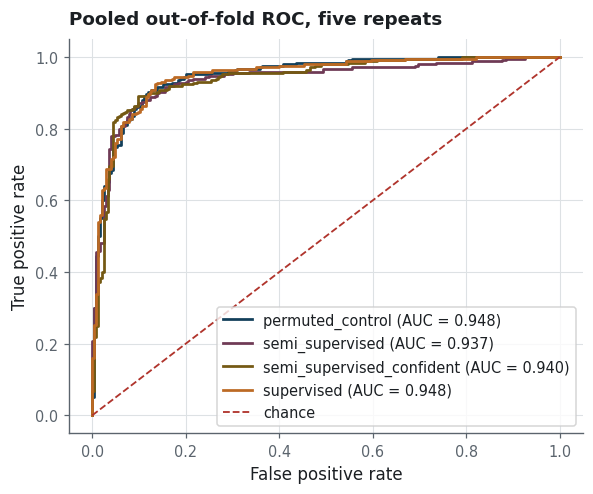

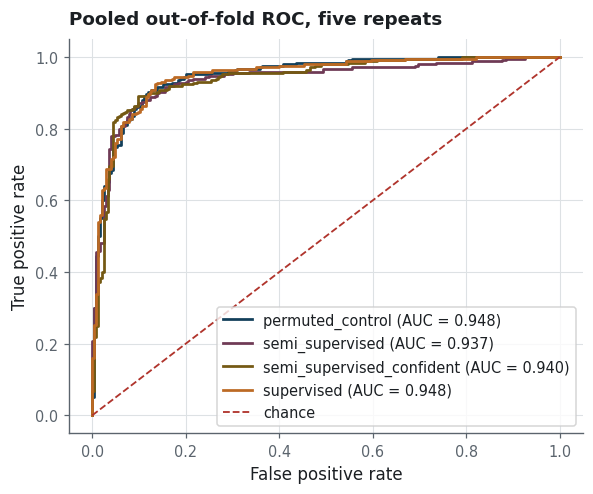

In [3]:
from mri_semisupervised.viz.plots import plot_roc_compare

curves = {
    arm: (group["y_true"].to_numpy(), group["y_score"].to_numpy())
    for arm, group in predictions.groupby("arm")
}
plot_roc_compare(curves, title="Pooled out-of-fold ROC, five repeats")

## 4. Which clustering method each fold picked

Choosing the method inside the fold means the choice can differ from one fold to the next.
That is not instability to hide — it is a measurement of how much the choice depended on
seeing every label.

In [4]:
print(folds["pseudo_method"].value_counts().to_string())
print()
print(f"ARI on the training labels: {folds['pseudo_ari_on_train'].mean():.3f} "
      f"+/- {folds['pseudo_ari_on_train'].std():.3f}")
print(f"pseudo-labels per fold    : {folds['n_pseudo'].mean():.0f}")

pseudo_method
Agglomerative(ward)    24
GMM                     1

ARI on the training labels: 0.457 +/- 0.096
pseudo-labels per fold    : 1311


## 2. What the leaks were worth

The `legacy` run reproduces the original protocol faithfully — duplicates left in place,
method and alignment decided once over every label, checkpoint taken on training accuracy.
It exists so the difference is **measured** here, and not quoted from an old file.

In [5]:
legacy_dir = EXPERIMENTS_DIR / "legacy"
if (legacy_dir / "per_fold.parquet").exists():
    legacy = pd.read_parquet(legacy_dir / "per_fold.parquet")
    comparison = pd.concat(
        [
            per_fold.groupby("arm")[headline].mean().add_suffix("_corrected"),
            legacy.groupby("arm")[headline].mean().add_suffix("_legacy"),
        ],
        axis=1,
    )
    display(comparison.round(3))
else:
    print("no legacy run found: uv run python scripts/run_experiment.py --mode legacy")

,roc_auc_corrected,pr_auc_corrected,recall_positive_corrected,f1_macro_corrected,accuracy_corrected,roc_auc_legacy,pr_auc_legacy,recall_positive_legacy,f1_macro_legacy,accuracy_legacy
arm,,,,,,,,,,
permuted_control,0.952,0.958,0.884,0.895,0.897,0.968,0.965,0.928,0.902,0.904
semi_supervised,0.958,0.964,0.888,0.881,0.883,0.959,0.953,0.880,0.898,0.900
semi_supervised_confident,0.945,0.948,0.880,0.898,0.899,NaN,NaN,NaN,NaN,NaN
supervised,0.966,0.963,0.920,0.904,0.905,0.964,0.963,0.928,0.911,0.912


## 3. What to take away

Whatever the numbers above say, the method is the point:

* an identity that comes from the data, so a duplicate cannot hide behind a folder;
* every decision that reads a label made inside the training fold;
* a control arm that makes "it helped" a falsifiable claim;
* intervals, because with twenty images per fold a difference of one image moves recall by
  0.05.

A protocol that can only confirm what you hoped is not a protocol.